##ROUN 1: DATA COLLECTION


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_file = '/content/drive/MyDrive/Portfolio_DAHR/Calibee/Data_Booking_Nanny.xlsx'
df = pd.read_excel(path_file)
print("Bảng dữ liệu File 1:")
display(df)

Bảng dữ liệu File 1:


,OPPORTUNITY No,Booking Date,Duty Date,Duty Time Start,End,Total hour,Location,Accomodation,Job Details No. of kids,Age,...,Special Requirements,Customer's Name,Booking Status,Note,Customer's Feedback,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,BB01,Mar 28,Mar 28,08:00:00,12:00:00,4,Da Nang,Danang ABC Kids Cafe,1.0,NaN,...,NaN,NaN,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BB02,Mar 28,Mar 30,13:30:00,20:30:00,7,Da Nang,Hyatt,1.0,NaN,...,NaN,NaN,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BB03,Mar 28,Mar 31,09:00:00,20:00:00,11,Da Nang,Hyatt,1.0,NaN,...,NaN,NaN,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BB04,Mar 28,Apr 1,09:00:00,20:00:00,11,Da Nang,Hyatt,1.0,NaN,...,NaN,NaN,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BB05,Mar 28,Apr 2,10:00:00,18:00:00,8,Da Nang,Hyatt,1.0,NaN,...,NaN,NaN,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,NaN,NaN,NaN,NaN,NaN,NaN,Phu Quoc,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250,NaN,NaN,NaN,NaN,NaN,NaN,Phu Quoc,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
251,NaN,NaN,NaN,NaN,NaN,NaN,Phu Quoc,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,NaN,NaN,NaN,NaN,NaN,NaN,Phu Quoc,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#ROUN2: DATA CLEANING AND STRUCTURING

In [ ]:
# ROUND 2: DATA CLEANING & FEATURE ENGINEERING

def clean_data_pipeline(df_input):
    df_clean = df_input.copy()
    df_clean.columns = df_clean.columns.str.strip()
    unnamed_cols = [c for c in df_clean.columns if 'Unnamed' in c]
    df_clean.drop(columns=unnamed_cols, inplace=True)
    df_clean.dropna(subset=['OPPORTUNITY No'], inplace=True)
    valid_statuses = ['Completed', 'Confirmed', 'Cancelled']
    sitter_keywords = ['assign', 'ms.', '카톡', '카풀', 'kim ji-won', 'tâm', 'nhi', 'phương']
    df_clean['Has_Sitter_Request'] = df_clean['Booking Status'].astype(str).apply(
        lambda x: True if any(kw in x.lower() for kw in sitter_keywords) else False
    )

    df_clean['Booking_Status_Clean'] = df_clean['Booking Status'].apply(
        lambda x: x if x in valid_statuses else ('Confirmed' if pd.notnull(x) else 'Unknown')
    )

    df_clean['No_of_Kids_Clean'] = pd.to_numeric(df_clean['Job Details No. of kids'], errors='coerce').fillna(1).astype(int)
    df_clean['No_of_Sitters_Clean'] = pd.to_numeric(df_clean['No. of sitters'], errors='coerce').fillna(1).astype(int)

    def parse_hours(val):
        if pd.isnull(val): return np.nan
        try:
            return float(val)
        except:
            return np.nan

    df_clean['Total_Hours_Clean'] = df_clean['Total hour'].apply(parse_hours)

    df_clean['Workforce_Hours'] = df_clean['Total_Hours_Clean'] * df_clean['No_of_Sitters_Clean']

    return df_clean

df_clean = clean_data_pipeline(df)

print("Đã làm sạch dữ liệu thành công!")
print(f"- Kích thước ban đầu: {df.shape}")
print(f"- Kích thước sau khi clean: {df_clean.shape}")
print("\nXem thử 5 dòng dữ liệu đã làm sạch:")
display(df_clean[['OPPORTUNITY No', 'Location', 'No_of_Kids_Clean', 'No_of_Sitters_Clean', 'Has_Sitter_Request', 'Booking_Status_Clean', 'Workforce_Hours']].head())

✅ Đã làm sạch dữ liệu thành công!
- Kích thước ban đầu: (254, 21)
- Kích thước sau khi clean: (244, 22)

Xem thử 5 dòng dữ liệu đã làm sạch:


,OPPORTUNITY No,Location,No_of_Kids_Clean,No_of_Sitters_Clean,Has_Sitter_Request,Booking_Status_Clean,Workforce_Hours
0,BB01,Da Nang,1,1,False,Completed,4.0
1,BB02,Da Nang,1,1,False,Completed,7.0
2,BB03,Da Nang,1,1,False,Completed,11.0
3,BB04,Da Nang,1,1,False,Completed,11.0
4,BB05,Da Nang,1,1,False,Completed,8.0


/tmp/ipykernel_2502/987640075.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=demand_by_loc, x='Location', y='Workforce_Hours', ax=axes[0, 0], palette='Blues_r')
/tmp/ipykernel_2502/987640075.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_2502/987640075.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_hours, x='Location', y='Total_Hours_Clean', ax=axes[1, 1], palette='YlGnBu_r')


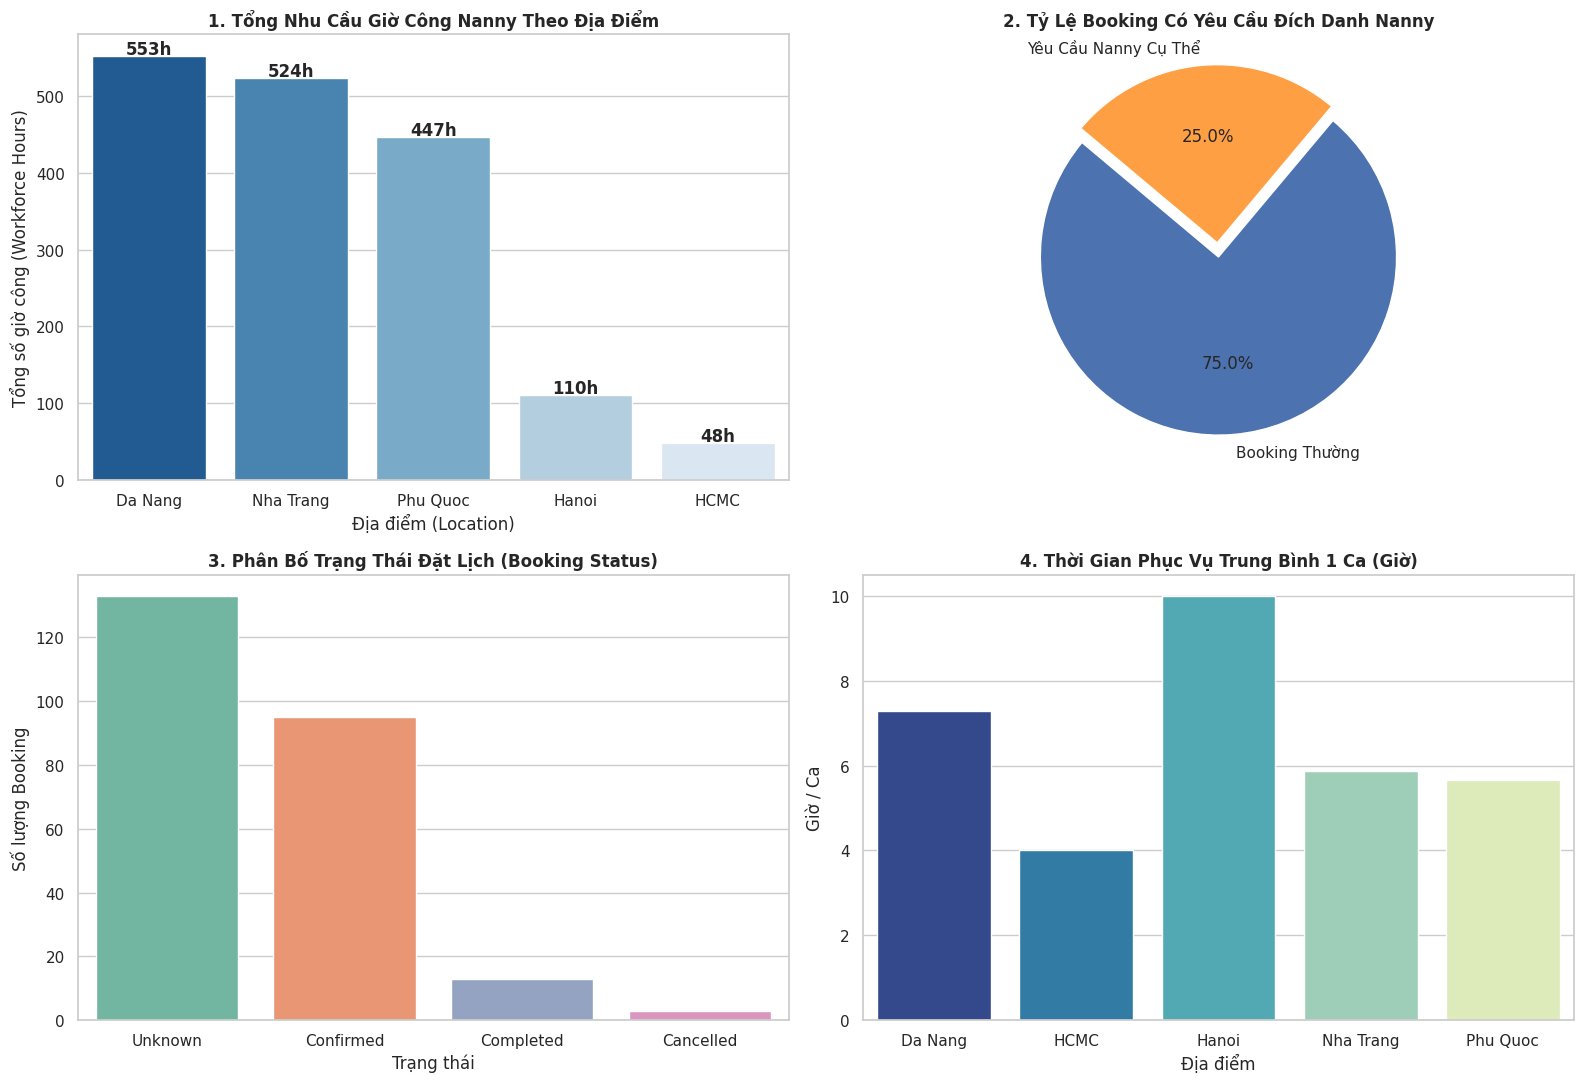


BÁO CÁO NHÂN SỰ TỔNG HỢP (HR METRICS SUMMARY)


,Location,Tong_Booking,Tong_Gio_Cong,TB_Gio_Moi_Ca,Ty_Le_Khach_Chon_Nanny
0,Da Nang,74,553.0,7.295455,9.5%
1,HCMC,6,48.0,4.000000,0.0%
2,Hanoi,11,110.0,10.000000,45.5%
3,Nha Trang,80,524.0,5.884615,33.8%
4,Phu Quoc,73,447.0,5.666667,30.1%


In [ ]:
# ROUND 3: EDA & HR WORKFORCE VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

demand_by_loc = df_clean.groupby('Location')['Workforce_Hours'].sum().reset_index().sort_values(by='Workforce_Hours', ascending=False)
sns.barplot(data=demand_by_loc, x='Location', y='Workforce_Hours', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('1. Tổng Nhu Cầu Giờ Công Nanny Theo Địa Điểm', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Địa điểm (Location)')
axes[0, 0].set_ylabel('Tổng số giờ công (Workforce Hours)')

for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height():.0f}h',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

sitter_req = df_clean['Has_Sitter_Request'].value_counts(normalize=True) * 100
axes[0, 1].pie(sitter_req, labels=['Booking Thường', 'Yêu Cầu Nanny Cụ Thể'],
               autopct='%1.1f%%', colors=['#4c72b0', '#ff9f43'], explode=(0, 0.08), startangle=140)
axes[0, 1].set_title('2. Tỷ Lệ Booking Có Yêu Cầu Đích Danh Nanny', fontsize=12, fontweight='bold')

status_counts = df_clean['Booking_Status_Clean'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Phân Bố Trạng Thái Đặt Lịch (Booking Status)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Trạng thái')
axes[1, 0].set_ylabel('Số lượng Booking')

avg_hours = df_clean.groupby('Location')['Total_Hours_Clean'].mean().reset_index()
sns.barplot(data=avg_hours, x='Location', y='Total_Hours_Clean', ax=axes[1, 1], palette='YlGnBu_r')
axes[1, 1].set_title('4. Thời Gian Phục Vụ Trung Bình 1 Ca (Giờ)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Địa điểm')
axes[1, 1].set_ylabel('Giờ / Ca')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("BÁO CÁO NHÂN SỰ TỔNG HỢP (HR METRICS SUMMARY)")
print("="*50)
hr_summary = df_clean.groupby('Location').agg(
    Tong_Booking=('OPPORTUNITY No', 'count'),
    Tong_Gio_Cong=('Workforce_Hours', 'sum'),
    TB_Gio_Moi_Ca=('Total_Hours_Clean', 'mean'),
    Ty_Le_Khach_Chon_Nanny=('Has_Sitter_Request', lambda x: f"{x.mean()*100:.1f}%")
).reset_index()

display(hr_summary)

In [ ]:
# ADVANCED DATA CLEANING: DATES & MISSING VALUES

import pandas as pd
import numpy as np

def full_clean_data_pipeline(df_input):
    df_clean = df_input.copy()

    df_clean.columns = df_clean.columns.str.strip()
    unnamed_cols = [c for c in df_clean.columns if 'Unnamed' in c]
    df_clean.drop(columns=unnamed_cols, inplace=True)
    df_clean.dropna(subset=['OPPORTUNITY No'], inplace=True)

    def parse_mixed_dates(val):
        if pd.isnull(val): return np.nan
        val_str = str(val).strip()
        try:
            return pd.to_datetime(val_str)
        except:
            try:
                return pd.to_datetime(val_str + " 2026", format='%b %d %Y')
            except:
                return pd.to_datetime(val_str, errors='coerce')

    df_clean['Duty_Date_Clean'] = df_clean['Duty Date'].apply(parse_mixed_dates)
    df_clean['Booking_Date_Clean'] = df_clean['Booking Date'].apply(parse_mixed_dates)
    df_clean['Duty_Date_Clean'].fillna(df_clean['Booking_Date_Clean'], inplace=True)
    df_clean['No_of_Kids_Clean'] = pd.to_numeric(df_clean['Job Details No. of kids'], errors='coerce').fillna(1).astype(int)
    df_clean['No_of_Sitters_Clean'] = pd.to_numeric(df_clean['No. of sitters'], errors='coerce').fillna(1).astype(int)

    def parse_hours(val):
        if pd.isnull(val): return np.nan
        try: return float(val)
        except: return np.nan

    df_clean['Total_Hours_Clean'] = df_clean['Total hour'].apply(parse_hours)
    median_hours = df_clean['Total_Hours_Clean'].median()
    df_clean['Total_Hours_Clean'].fillna(median_hours, inplace=True) # Fill NA

    df_clean['Workforce_Hours'] = df_clean['Total_Hours_Clean'] * df_clean['No_of_Sitters_Clean']
    valid_statuses = ['Completed', 'Confirmed', 'Cancelled']
    sitter_keywords = ['assign', 'ms.', '카톡', '카풀', 'kim ji-won', 'tâm', 'nhi', 'phương']

    df_clean['Has_Sitter_Request'] = df_clean['Booking Status'].astype(str).apply(
        lambda x: True if any(kw in x.lower() for kw in sitter_keywords) else False
    )
    df_clean['Booking_Status_Clean'] = df_clean['Booking Status'].apply(
        lambda x: x if x in valid_statuses else ('Confirmed' if pd.notnull(x) else 'Confirmed/Pending')
    )
    df_clean['Special Requirements'] = df_clean['Special Requirements'].fillna('None')
    df_clean['Customer\'s Feedback'] = df_clean['Customer\'s Feedback'].fillna('No Feedback')

    return df_clean

df_clean = full_clean_data_pipeline(df)

print("ĐÃ CHUẨN HÓA TOÀN BỘ NGÀY THÁNG VÀ XỬ LÝ MISSING VALUES!")
print(f"Số lượng Missing Values còn lại ở các cột chính:")
print(df_clean[['Duty_Date_Clean', 'Total_Hours_Clean', 'No_of_Kids_Clean', 'Booking_Status_Clean']].isnull().sum())

✅ ĐÃ CHUẨN HÓA TOÀN BỘ NGÀY THÁNG VÀ XỬ LÝ MISSING VALUES!
Số lượng Missing Values còn lại ở các cột chính:
Duty_Date_Clean         175
Total_Hours_Clean         0
No_of_Kids_Clean          0
Booking_Status_Clean      0
dtype: int64


/tmp/ipykernel_2502/2319696949.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Duty_Date_Clean'].fillna(df_clean['Booking_Date_Clean'], inplace=True)
/tmp/ipykernel_2502/2319696949.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [ ]:
import pandas as pd
import numpy as np
import re
import datetime

def full_action_project_pipeline(df_input):
    df_clean = df_input.copy()

    df_clean.columns = df_clean.columns.str.strip()
    unnamed_cols = [c for c in df_clean.columns if 'Unnamed' in c]
    df_clean.drop(columns=unnamed_cols, inplace=True)
    df_clean.dropna(subset=['OPPORTUNITY No'], inplace=True)

In [ ]:
import pandas as pd
import numpy as np
import re
import datetime
df_master = df.copy()

In [ ]:
# STEP 1: CẤU TRÚC BẢNG & TÊN CỘT
df_master.columns = df_master.columns.str.strip()
unnamed_cols = [c for c in df_master.columns if 'Unnamed' in c]
df_master.drop(columns=unnamed_cols, inplace=True)
df_master.dropna(subset=['OPPORTUNITY No'], inplace=True)

# STEP 2: PARSE NGÀY THÁNG THÔNG MINH (ROBUST DATE PARSING)
def parse_date_robust(val):
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    if isinstance(val, (pd.Timestamp, datetime.date, datetime.datetime)):
        return pd.to_datetime(val)

    cleaned = re.sub(r'([a-zA-Z]+)(\d+)', r'\1 \2', val_str)
    if not re.search(r'\b20\d{2}\b', cleaned):
        cleaned = cleaned + " 2026"

    try:
        return pd.to_datetime(cleaned)
    except:
        return pd.to_datetime(val_str, errors='coerce')

df_master['Duty_Date_Clean'] = df_master['Duty Date'].apply(parse_date_robust)
df_master['Booking_Date_Clean'] = df_master['Booking Date'].apply(parse_date_robust)
df_master['Duty_Date_Clean'].fillna(df_master['Booking_Date_Clean'], inplace=True)

df_master['Duty_Month'] = df_master['Duty_Date_Clean'].dt.month_name()
df_master['Duty_DayOfWeek'] = df_master['Duty_Date_Clean'].dt.day_name()
df_master['Is_Weekend'] = df_master['Duty_Date_Clean'].dt.dayofweek.isin([5, 6])

/tmp/ipykernel_2502/3259396754.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master['Duty_Date_Clean'].fillna(df_master['Booking_Date_Clean'], inplace=True)


In [ ]:
# STEP 3: CHUẨN HÓA NUMERIC & MISSING VALUES IMPUTATION
df_master['No_of_Kids_Clean'] = pd.to_numeric(df_master['Job Details No. of kids'], errors='coerce').fillna(1).astype(int)
df_master['No_of_Sitters_Clean'] = pd.to_numeric(df_master['No. of sitters'], errors='coerce').fillna(1).astype(int)
df_master['Kids_Per_Sitter_Ratio'] = df_master['No_of_Kids_Clean'] / df_master['No_of_Sitters_Clean']

def parse_hours(val):
    if pd.isnull(val):
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

df_master['Total_Hours_Clean'] = df_master['Total hour'].apply(parse_hours)
median_hours = df_master['Total_Hours_Clean'].median()
df_master['Total_Hours_Clean'].fillna(median_hours, inplace=True)
df_master['Workforce_Hours'] = df_master['Total_Hours_Clean'] * df_master['No_of_Sitters_Clean']

/tmp/ipykernel_2502/4073992589.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master['Total_Hours_Clean'].fillna(median_hours, inplace=True)


In [ ]:
# STEP 4: TÁCH CỘT TEXT & TẠO CÁC CỘT KỸ NĂNG (DÀNH CHO ĐỀ TÀI 2)
valid_statuses = ['Completed', 'Confirmed', 'Cancelled']
sitter_keywords = ['assign', 'ms.', '카톡', '카풀', 'kim ji-won', 'tâm', 'nhi', 'phương']

df_master['Has_Specific_Sitter_Request'] = df_master['Booking Status'].astype(str).apply(
    lambda x: True if any(kw in x.lower() for kw in sitter_keywords) else False
)

df_master['Booking_Status_Clean'] = df_master['Booking Status'].apply(
    lambda x: x if x in valid_statuses else ('Confirmed' if pd.notnull(x) else 'Confirmed/Pending')
)

def extract_special_skills(row):
    text = str(row['Special Requirements']).lower() + " " + str(row['Booking Status']).lower() + " " + str(row['Note']).lower()
    skills = []
    if any(k in text for k in ['korean', '카톡', '카풀', 'ko']):
        skills.append('Korean Speaking')
    if any(k in text for k in ['english', 'en']):
        skills.append('English Speaking')
    if any(k in text for k in ['infant', 'baby', 'sơ sinh', '0yo', '1yo', 'months', 'tháng']):
        skills.append('Infant Care')
    if any(k in text for k in ['ba na', 'bà nà', 'bana']):
        skills.append('Outdoor/Ba Na Hills Tour')
    return ", ".join(skills) if skills else 'General Care'

df_master['Special_Skill_Req'] = df_master.apply(extract_special_skills, axis=1)

In [ ]:
# STEP 5: FILL MISSING CHO CÁC CỘT CATEGORICAL
df_master['Location_Clean'] = df_master['Location'].fillna('Unknown').str.strip().str.title()
df_master['Accomodation_Clean'] = df_master['Accomodation'].fillna('Other/Private').str.strip()
df_master['Age_Clean'] = df_master['Age'].fillna('Not Specified')
df_master['Special Requirements'] = df_master['Special Requirements'].fillna('None')
df_master['Customer\'s Feedback'] = df_master['Customer\'s Feedback'].fillna('No Feedback')

print("ĐÃ XỬ LÝ HOÀN HẢO NGUYÊN BẢN DỮ LIỆU CẢ 2 ĐỀ TÀI!")
print(f"- Kích thước Dataset mới: {df_master.shape[0]} dòng, {df_master.shape[1]} cột")

display_cols = [
    'OPPORTUNITY No', 'Duty_Date_Clean', 'Location_Clean', 'Is_Weekend',
    'No_of_Kids_Clean', 'No_of_Sitters_Clean', 'Kids_Per_Sitter_Ratio',
    'Workforce_Hours', 'Has_Specific_Sitter_Request', 'Special_Skill_Req'
]
df_master[display_cols].head()

✅ ĐÃ XỬ LÝ HOÀN HẢO NGUYÊN BẢN DỮ LIỆU CẢ 2 ĐỀ TÀI!
- Kích thước Dataset mới: 244 dòng, 32 cột


,OPPORTUNITY No,Duty_Date_Clean,Location_Clean,Is_Weekend,No_of_Kids_Clean,No_of_Sitters_Clean,Kids_Per_Sitter_Ratio,Workforce_Hours,Has_Specific_Sitter_Request,Special_Skill_Req
0,BB01,2026-03-28,Da Nang,True,1,1,1.0,4.0,False,General Care
1,BB02,2026-03-30,Da Nang,False,1,1,1.0,7.0,False,General Care
2,BB03,2026-03-31,Da Nang,False,1,1,1.0,11.0,False,General Care
3,BB04,2026-04-01,Da Nang,False,1,1,1.0,11.0,False,General Care
4,BB05,2026-04-02,Da Nang,False,1,1,1.0,8.0,False,General Care


###ROUN 3: EDA

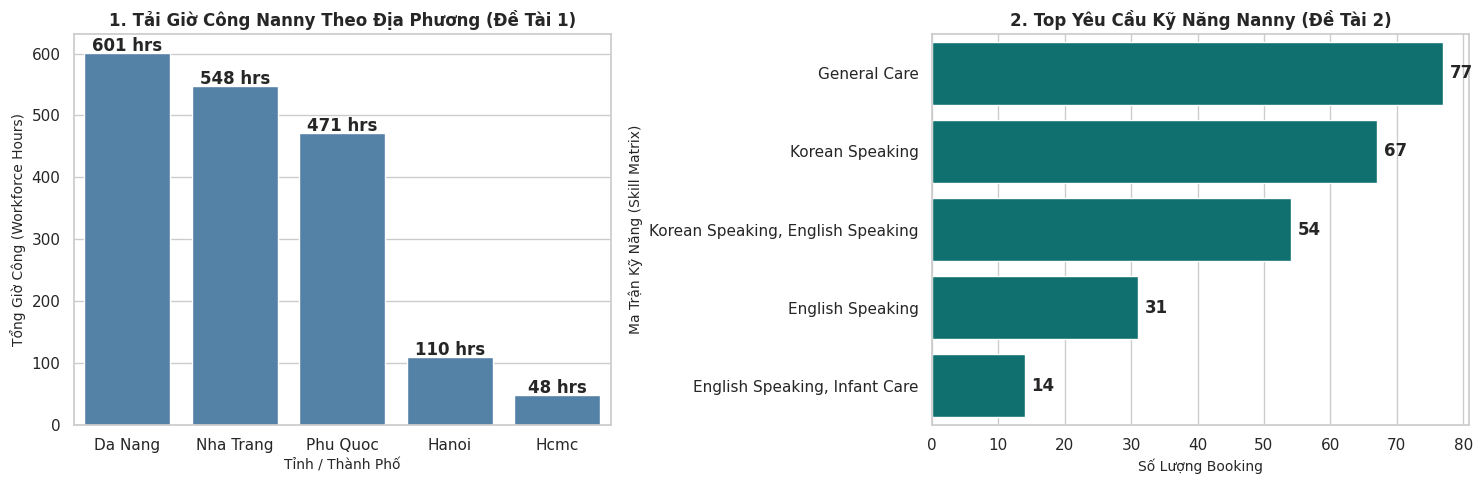

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. BIỂU ĐỒ TỔNG NHU CẦU GIỜ CÔNG NANNY THEO ĐỊA PHƯƠNG
demand_by_loc = df_master.groupby('Location_Clean')['Workforce_Hours'].sum().reset_index().sort_values(by='Workforce_Hours', ascending=False)

sns.barplot(data=demand_by_loc, x='Location_Clean', y='Workforce_Hours', color='steelblue', ax=axes[0])
axes[0].set_title('1. Tải Giờ Công Nanny Theo Địa Phương (Đề Tài 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tỉnh / Thành Phố', fontsize=10)
axes[0].set_ylabel('Tổng Giờ Công (Workforce Hours)', fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} hrs',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# 2. BIỂU ĐỒ TOP YÊU CẦU KỸ NĂNG CỦA KHÁCH HÀNG (ĐỀ TÀI 2)
skill_summary = df_master['Special_Skill_Req'].value_counts().head(5).reset_index()
skill_summary.columns = ['Skill', 'Count']

sns.barplot(data=skill_summary, y='Skill', x='Count', color='teal', ax=axes[1])
axes[1].set_title('2. Top Yêu Cầu Kỹ Năng Nanny (Đề Tài 2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số Lượng Booking', fontsize=10)
axes[1].set_ylabel('Ma Trận Kỹ Năng (Skill Matrix)', fontsize=10)

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}',
                    (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
"""
Fix script for Data_Booking_Nanny_Cleaned.csv
--------------------------------------------
1. Total_Hours_Clean: recompute from Duty Time Start / End for rows where
   the original 'Total hour' was missing but start/end time still exist.
   Only fall back to a default (median) when BOTH start and end are also missing.
2. Location_Clean: standardize casing so "Hcmc" -> "HCMC" (keep other
   locations as-is since they are already Title Case).

Run: python3 fix_booking_data.py
Input : Data_Booking_Nanny_Cleaned.csv
Output: Data_Booking_Nanny_Cleaned_FIXED.csv
"""

import pandas as pd

INPUT_FILE = "Data_Booking_Nanny_Cleaned.csv"
OUTPUT_FILE = "Data_Booking_Nanny_Cleaned_FIXED.csv"

df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")

# FIX #1: Total_Hours_Clean
def calc_hours_from_start_end(row):
    """Return duration in hours between Duty Time Start and End, or None
    if either value is missing / unparseable. Handles overnight shifts
    (End earlier than Start) by adding 24h."""
    start_raw = row["Duty Time Start"]
    end_raw = row["End"]
    if pd.isnull(start_raw) or pd.isnull(end_raw):
        return None
    try:
        start = pd.to_datetime(start_raw)
        end = pd.to_datetime(end_raw)
    except Exception:
        return None
    diff = (end - start).total_seconds() / 3600
    if diff < 0:
        diff += 24
    return round(diff, 2)

# Only touch rows where the ORIGINAL 'Total hour' was missing
missing_mask = df["Total hour"].isnull()

recalculated = df.loc[missing_mask].apply(calc_hours_from_start_end, axis=1)
n_recalculated = recalculated.notnull().sum()

df.loc[missing_mask, "Total_Hours_Clean"] = recalculated.combine_first(
    df.loc[missing_mask, "Total_Hours_Clean"]
)

still_null_mask = df["Total_Hours_Clean"].isnull()
n_still_null = still_null_mask.sum()
fallback_median = df.loc[~still_null_mask, "Total_Hours_Clean"].median()
df.loc[still_null_mask, "Total_Hours_Clean"] = fallback_median

df["Workforce_Hours"] = df["Total_Hours_Clean"] * df["No_of_Sitters_Clean"]

print(f"[Fix #1] Recalculated {n_recalculated} rows from Start/End time.")
print(f"[Fix #1] Filled {n_still_null} rows with fallback median "
      f"({fallback_median}h) — both Start & End were also missing.")
location_fix_map = {
    "Hcmc": "Ho Chi Minh",
}

before_counts = df["Location_Clean"].value_counts()
df["Location_Clean"] = df["Location_Clean"].replace(location_fix_map)
after_counts = df["Location_Clean"].value_counts()

print("\n[Fix #2] Location_Clean value counts BEFORE:")
print(before_counts)
print("\n[Fix #2] Location_Clean value counts AFTER:")
print(after_counts)

# Save output
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"\nSaved fixed file to: {OUTPUT_FILE}")

[Fix #1] Recalculated 8 rows from Start/End time.
[Fix #1] Filled 0 rows with fallback median (6.0h) — both Start & End were also missing.

[Fix #2] Location_Clean value counts BEFORE:
Location_Clean
Nha Trang    80
Da Nang      74
Phu Quoc     73
Hanoi        11
Hcmc          6
Name: count, dtype: int64

[Fix #2] Location_Clean value counts AFTER:
Location_Clean
Nha Trang      80
Da Nang        74
Phu Quoc       73
Hanoi          11
Ho Chi Minh     6
Name: count, dtype: int64

Saved fixed file to: Data_Booking_Nanny_Cleaned_FIXED.csv


In [ ]:
output_csv_filename = 'Data_Booking_Nanny_Cleaned.csv'
df_master.to_csv(output_csv_filename, index=False, encoding='utf-8-sig')

print(f"Đã xuất thành công file CSV: {output_csv_filename}")

🎉 Đã xuất thành công file CSV: Data_Booking_Nanny_Cleaned.csv
